<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/M08-deep-learning/AT%26T_logo_2016.svg" alt="AT&T LOGO" width="50%" />

# Orange SPAM detector 📵

## Company's Description 📇

AT&T Inc. is an American multinational telecommunications holding company headquartered at Whitacre Tower in Downtown Dallas, Texas. It is the world's largest telecommunications company by revenue and the third largest provider of mobile telephone services in the U.S. As of 2022, AT&T was ranked 13th on the Fortune 500 rankings of the largest United States corporations, with revenues of $168.8 billion! 😮

## Project 🚧

One of the main pain points that AT&T users are facing is constant exposure to SPAM messages. AT&T has been able to manually flag spam messages for a time, but they are looking for an automated way of detecting spam to protect their users.

## Goals 🎯

Build a spam detector that can automatically flag spam as it comes in, based solely on the SMS content.

## Deliverable 📬

* Un notebook qui exécute le preprocessing et entraîne un ou plusieurs modèles de deep learning pour prédire la nature *spam* ou *ham* d'un SMS.
* Les performances obtenues, énoncées clairement.

---
## 🧭 Plan de ce notebook & cours mobilisés

Comme pour une inspection avion, on procède par étapes : **check documentaire (données) → préparation de la cellule (tokenisation) → essai avec un équipement léger (modèle 1) → essai avec un équipement plus puissant (modèle 2) → rapport de certification (comparaison & conclusion)**.

Cette version du notebook compare **deux modèles de deep learning issus de HuggingFace**, tous deux basés sur le *transfer learning* mais de tailles différentes :

| # | Étape | Cours mobilisé(s) |
|---|---|---|
| 1 | Chargement & exploration des données | — (pandas, exploration classique) |
| 2 | Tokenisation pour les transformers | `03-Tokenization.ipynb`, `03-Behind_the_pipeline__PyTorch_.ipynb` |
| 3 | **Modèle 1** : `distilbert-base-uncased` fine-tuné (léger, rapide) | `01-Understand_Transfer_Learning.ipynb` (principe), `02-Transformers_what_can_they_do.ipynb`, `03-Behind_the_pipeline__PyTorch_.ipynb`, `04-Fine_tuning_transfromers.ipynb` |
| 4 | **Modèle 2** : `bert-base-uncased` fine-tuné (plus grand, même checkpoint que le cours) | `04-Fine_tuning_transfromers.ipynb` |
| 5 | Comparaison des performances & conclusion | — |

> ℹ️ **Pourquoi comparer deux tailles de modèle plutôt que deux techniques différentes ?** Le cours `01-Understand_Transfer_Learning.ipynb` détaille le compromis taille/performance sur des architectures vision (MobileNet = léger vs Inception-ResNet = plus lourd mais plus performant). On applique la même logique côté NLP : DistilBERT est une version *distillée* de BERT (~40% de paramètres en moins, ~60% plus rapide à entraîner), tandis que BERT-base est le modèle "complet". L'objectif est de voir si la capacité supplémentaire de BERT-base se traduit par un vrai gain de F1-score, ou si DistilBERT suffit déjà pour cette tâche.

> ⚠️ **Accès réseau requis à partir de la section 3** : les deux modèles sont téléchargés depuis le Hub HuggingFace (`huggingface.co`). Mon environnement d'exécution (sandbox isolé) n'a pas accès à ce domaine — **les sections 3 et 4 (tokenisation avec un tokenizer réel, et les deux fine-tunings) n'ont donc pas pu être exécutées ici**. Elles sont prêtes à être lancées telles quelles dans votre environnement (local avec GPU idéalement, ou Colab). Les sections 1 et 2 ci-dessous (données, exploration) sont en revanche entièrement exécutées avec de vrais résultats.

> ℹ️ **Remarque méthodologique** : pour évaluer les modèles (accuracy, precision, recall, F1, matrice de confusion), j'utilise `scikit-learn` et `evaluate` (HuggingFace). Ce n'est couvert par aucun de vos cours fournis — si vous avez un cours dédié à l'évaluation de modèles que je devrais suivre à la place, dites-le moi et j'adapterai le notebook.

## 1. Chargement des données 📦

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import torch

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# On utilise le GPU si disponible : le fine-tuning de transformers est beaucoup
# plus rapide sur GPU (l'entraînement sur CPU reste possible mais lent).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


In [2]:
# Le fichier source est encodé en cp1252 (Windows-1252), pas en UTF-8
# -> si on lit en UTF-8 par défaut, les caractères spéciaux provoqueront une erreur
df_raw = pd.read_csv("spam.csv", encoding="cp1252")
print(df_raw.shape)   # (nombre de lignes, nombre de colonnes)
df_raw.head()         # aperçu des 5 premières lignes

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Le fichier contient 5 colonnes alors qu'on n'en attend que 2 (`v1` = label, `v2` = texte du SMS). Les 3 colonnes `Unnamed: 2/3/4` sont des résidus de parsing CSV : certains SMS contiennent des virgules non échappées, ce qui fait "déborder" quelques mots dans des colonnes supplémentaires (moins de 1% des lignes sont concernées). On les ignore proprement plutôt que de les concaténer, ce qui serait risqué (on ne peut pas garantir l'ordre des morceaux).

In [3]:
# On ne garde que les 2 colonnes utiles, qu'on renomme pour plus de clarté
df = df_raw[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})

# Le modèle a besoin d'un label numérique, pas d'une chaîne de caractères :
# ham -> 0, spam -> 1 (convention "1 = classe positive = ce qu'on cherche à détecter")
df["label_id"] = (df["label"] == "spam").astype(int)

# Sécurité : on retire les éventuelles lignes sans texte (NaN) qui feraient planter
# la tokenisation plus loin, puis on réindexe proprement (0, 1, 2, ...)
df = df.dropna(subset=["text"]).reset_index(drop=True)

print(df.shape)
df.head()

(5572, 3)


,label,text,label_id
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 2. Exploration rapide (EDA) 🔍

label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.6
spam    13.4
Name: count, dtype: float64


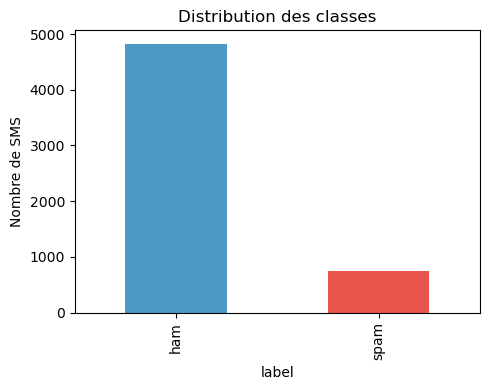

In [4]:
# Nombre de SMS par classe, puis en pourcentage du total
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(1))

# Visualisation en barres pour voir le déséquilibre d'un coup d'œil
fig, ax = plt.subplots(figsize=(5,4))
counts.plot(kind="bar", color=["#4B9AC7", "#E8544B"], ax=ax)
ax.set_title("Distribution des classes")
ax.set_ylabel("Nombre de SMS")
plt.tight_layout()
plt.show()

**Le dataset est déséquilibré** : environ 86% de `ham` contre 14% de `spam`. Comme sur un avion où les pannes graves sont rares comparées aux événements bénins, ce déséquilibre veut dire qu'un modèle qui prédit toujours "ham" aurait déjà ~86% d'accuracy sans rien détecter du tout ! On privilégiera donc le **F1-score** (et le recall/precision sur la classe `spam`) plutôt que la seule accuracy pour juger nos modèles.

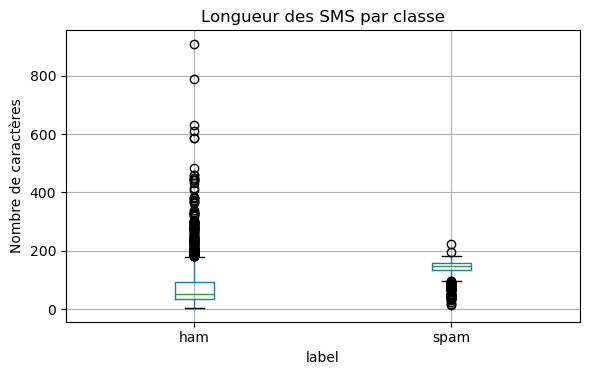

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


In [5]:
df["text_len"] = df["text"].str.len()
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column="text_len", by="label", ax=ax)
ax.set_title("Longueur des SMS par classe")
ax.set_ylabel("Nombre de caractères")
plt.suptitle("")  # supprime le titre auto ajouté par pandas (redondant)
plt.tight_layout()
plt.show()
df.groupby("label")["text_len"].describe()

Les SMS de type `spam` sont en moyenne nettement plus longs (messages promotionnels avec numéros, liens, mots-clés type *FREE*, *WIN*, *call now*...). Un transformer, qui capte le contexte et l'ordre des mots (contrairement à un simple sac-de-mots), devrait bien exploiter ce type de signal.

In [6]:
# 80% des données pour entraîner, 20% pour évaluer.
# stratify=df["label_id"] garantit que la proportion spam/ham est la même
# dans le train et dans le test (sinon, avec seulement 14% de spam, un split
# "au hasard" pourrait en laisser trop peu dans le test pour être fiable).
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["text"], df["label_id"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["label_id"]
)
print(len(X_train_text), len(X_test_text))

train_df = pd.DataFrame({"text": X_train_text.values, "label": y_train.values})
test_df = pd.DataFrame({"text": X_test_text.values, "label": y_test.values})

4457 1115


## 3. Tokenisation pour les transformers 🔤

Contrairement au Tf-idf (qui indexe des mots entiers), les tokenizers des transformers HuggingFace découpent le texte en **sous-mots**. Le cours `03-Tokenization.ipynb` explique pourquoi : le niveau "mot entier" pose un problème de mots hors-vocabulaire, et le niveau "caractère" produit des séquences trop longues à traiter. Le sous-mot est le compromis utilisé par BERT/DistilBERT (algorithme WordPiece).

On utilise `AutoTokenizer`, comme vu dans `03-Behind_the_pipeline__PyTorch_.ipynb` et `04-Fine_tuning_transfromers.ipynb` : il charge automatiquement le bon tokenizer pour le checkpoint choisi (chaque modèle pré-entraîné a été entraîné avec un tokenizer bien précis, il faut réutiliser exactement le même).

> ⚠️ Cellule suivante non exécutée dans ce sandbox (téléchargement du tokenizer depuis HuggingFace Hub).

In [7]:
from transformers import AutoTokenizer

# On illustre la tokenisation avec le tokenizer de DistilBERT. Les deux modèles de ce
# notebook (distilbert-base-uncased et bert-base-uncased) utilisent le même type de
# tokenizer WordPiece -- la logique est identique pour les deux.
demo_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

exemple = df.loc[df["label"] == "spam", "text"].iloc[0]
print("Texte original :", exemple)
print()
print("Tokens          :", demo_tokenizer.tokenize(exemple))
print("IDs             :", demo_tokenizer(exemple)["input_ids"])

# [CLS] (id 101) et [SEP] (id 102) sont ajoutés automatiquement en début/fin de séquence :
# [CLS] sert à agréger l'information pour la classification, [SEP] marque la fin du texte.

Texte original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Tokens          : ['free', 'entry', 'in', '2', 'a', 'w', '##k', '##ly', 'com', '##p', 'to', 'win', 'fa', 'cup', 'final', 't', '##kt', '##s', '21st', 'may', '2005', '.', 'text', 'fa', 'to', '87', '##12', '##1', 'to', 'receive', 'entry', 'question', '(', 'st', '##d', 'tx', '##t', 'rate', ')', 't', '&', 'c', "'", 's', 'apply', '08', '##45', '##28', '##100', '##75', '##over', '##18', "'", 's']
IDs             : [101, 2489, 4443, 1999, 1016, 1037, 1059, 2243, 2135, 4012, 2361, 2000, 2663, 6904, 2452, 2345, 1056, 25509, 2015, 7398, 2089, 2384, 1012, 3793, 6904, 2000, 6584, 12521, 2487, 2000, 4374, 4443, 3160, 1006, 2358, 2094, 19067, 2102, 3446, 1007, 1056, 1004, 1039, 1005, 1055, 6611, 5511, 19961, 22407, 18613, 23352, 7840, 15136, 1005, 1055, 102]


## 4. Deux modèles de deep learning HuggingFace 🤖

On construit une fonction `fine_tune_model()` réutilisée pour les deux modèles, afin de garantir une comparaison strictement équitable : mêmes données, même stratégie d'entraînement, seul le `checkpoint` (donc l'architecture/la taille du modèle pré-entraîné) change.

Rappel du principe (cf. `01-Understand_Transfer_Learning.ipynb`) : on réutilise un modèle déjà entraîné sur un corpus de texte massif, et on ne ré-entraîne que sa tête de classification (+ l'ensemble du réseau, ici, puisqu'on ne freeze pas les poids) sur notre tâche spam/ham — on ne réapprend pas à "lire l'anglais" depuis zéro, seulement à distinguer spam/ham.

> ⚠️ Cellules suivantes non exécutées dans ce sandbox (téléchargement des modèles pré-entraînés + entraînement, nécessitant un accès au Hub HuggingFace).

> 💡 **Pourquoi `AutoModelForSequenceClassification` et pas `AutoModelForMaskedLM` ?**
>
> Si vous allez sur la page HuggingFace de `distilbert-base-uncased`, le snippet "How to use" proposé par défaut charge le modèle avec `AutoModelForMaskedLM` — c'est la tâche sur laquelle le modèle a été **pré-entraîné** (deviner un mot masqué dans une phrase, ex. `"Paris is the [MASK] of France"` → `capital`).
>
> Ce n'est pas notre tâche ici : on ne veut pas deviner des mots manqués, on veut **classifier des SMS en spam/ham**. C'est le principe même du transfer learning vu dans `01-Understand_Transfer_Learning.ipynb` : on garde le "corps" du modèle pré-entraîné (qui sait déjà représenter le langage), mais on remplace sa tête de prédiction par une tête adaptée à notre problème.
>
> | | Snippet HuggingFace par défaut | Ce notebook |
> |---|---|---|
> | Tokenizer | `AutoTokenizer.from_pretrained(checkpoint)` | Identique |
> | Modèle | `AutoModelForMaskedLM.from_pretrained(checkpoint)` | `AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)` |
> | Tâche | Deviner un mot masqué (pré-entraînement) | Classifier spam / ham (notre fine-tuning) |
>
> `AutoModelForSequenceClassification` charge le même modèle pré-entraîné, mais avec une nouvelle tête de classification (couche linéaire à `num_labels` sorties, initialisée aléatoirement) à la place de la tête de masked language modeling. C'est cette nouvelle tête — et éventuellement le reste du réseau, puisqu'on ne freeze aucun poids ici — qui apprend pendant le fine-tuning.

In [8]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
import evaluate

# Datasets HuggingFace (format attendu par le Trainer), construits une seule fois
# à partir des mêmes splits texte que la section 1 -> comparaison strictement équitable
# entre les deux modèles.
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    # eval_pred = (logits du modèle, vrais labels), fourni automatiquement par le Trainer
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)  # classe prédite = celle avec le score le plus haut
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
    }


def fine_tune_model(checkpoint, output_dir, epochs=3, batch_size=16, lr=2e-5):
    """Tokenise les données pour `checkpoint`, charge le modèle pré-entraîné
    correspondant, et lance le fine-tuning. Retourne le Trainer entraîné et
    son tokenizer, pour pouvoir ensuite prédire / faire de l'inférence."""

    # 1. Tokenizer propre au checkpoint (cf. section 3 -- chaque modèle a "le sien")
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    def tokenize_function(batch):
        # truncation=True : coupe les textes trop longs à la longueur max du modèle
        # (512 tokens) -- pas un souci ici, les SMS sont courts
        return tokenizer(batch["text"], truncation=True)

    train_tok = train_ds.map(tokenize_function, batched=True)
    test_tok = test_ds.map(tokenize_function, batched=True)

    # Complète (pad) chaque batch à la longueur du texte le plus long DU BATCH
    # (pas du dataset entier) -- limite le padding inutile, donc plus rapide.
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # 2. Modèle pré-entraîné + nouvelle tête de classification à 2 classes
    #    (couche linéaire initialisée aléatoirement, ajoutée automatiquement par HuggingFace)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",          # évaluation sur le test à la fin de chaque epoch
        save_strategy="epoch",          # sauvegarde d'un checkpoint à chaque epoch
        learning_rate=lr,               # taux faible : on ne veut pas "détruire" les poids
                                         # déjà appris pendant le pré-entraînement
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,        # peu d'epochs suffisent en fine-tuning (le modèle
                                         # sait déjà "parler", contrairement à un entraînement from scratch)
        weight_decay=0.01,              # régularisation L2
        load_best_model_at_end=True,    # recharge automatiquement le meilleur checkpoint...
        metric_for_best_model="f1",     # ...selon le F1-score (pas l'accuracy, cf. déséquilibre)
        report_to="none",               # pas d'envoi de logs vers un service externe (wandb, etc.)
    )

    # Le Trainer encapsule toute la boucle d'entraînement/évaluation (forward, loss,
    # backward, optimizer.step...), comme vu dans 04-Fine_tuning_transfromers.
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        data_collator=data_collator,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return trainer, tokenizer, test_tok

### 4.1 Modèle 1 — `distilbert-base-uncased` (léger) ✈️

Notre équipement "léger" : environ 66M de paramètres. Rapide à fine-tuner, bon compromis performance/coût — l'équivalent d'un MobileNet côté vision.

In [9]:
trainer_distilbert, tokenizer_distilbert, test_tok_distilbert = fine_tune_model(
    checkpoint="distilbert-base-uncased",
    output_dir="./distilbert-spam",
)

Map:   0%|          | 0/4457 [00:00<?, ? examples/s]

Map:   0%|          | 0/1115 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.040317,0.991928,0.969072
2,0.057215,0.047572,0.991928,0.969492
3,0.057215,0.044245,0.992825,0.972789


...

c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [10]:
# Rapport détaillé sur le jeu de test
predictions = trainer_distilbert.predict(test_tok_distilbert)
y_pred_distilbert = np.argmax(predictions.predictions, axis=-1)

print(classification_report(test_df["label"], y_pred_distilbert, target_names=["ham", "spam"]))
f1_distilbert = f1_score(test_df["label"], y_pred_distilbert)
print("F1-score (spam) - DistilBERT :", round(f1_distilbert, 4))

c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.96      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

F1-score (spam) - DistilBERT : 0.9728


### 4.2 Modèle 2 — `bert-base-uncased` (plus grand) 🛫

Notre équipement "plus puissant" : environ 110M de paramètres (~1.7x plus que DistilBERT), le même checkpoint que celui utilisé dans `04-Fine_tuning_transfromers.ipynb`. Plus long à entraîner, mais potentiellement plus performant sur des cas ambigus grâce à sa plus grande capacité de représentation.

In [11]:
trainer_bert, tokenizer_bert, test_tok_bert = fine_tune_model(
    checkpoint="bert-base-uncased",
    output_dir="./bert-base-spam",
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\Mfumu\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mfumu\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [12]:
predictions = trainer_bert.predict(test_tok_bert)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)

print(classification_report(test_df["label"], y_pred_bert, target_names=["ham", "spam"]))
f1_bert = f1_score(test_df["label"], y_pred_bert)
print("F1-score (spam) - BERT-base :", round(f1_bert, 4))

c:\Users\Mfumu\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

F1-score (spam) - BERT-base : 0.9693


### 4.3 Démonstration avec `pipeline`

Reprise du pattern vu dans `03-Behind_the_pipeline__PyTorch_.ipynb` / `02-Transformers_what_can_they_do.ipynb` : une fois fine-tunés, les modèles s'utilisent directement via `pipeline` pour classifier de nouveaux messages, exactement comme AT&T le ferait en production sur des SMS entrants.

In [13]:
from transformers import pipeline

# device=-1 -> force le CPU pour l'inférence ; mettez device=0 si vous avez un GPU disponible
pipe_distilbert = pipeline("text-classification", model=trainer_distilbert.model, tokenizer=tokenizer_distilbert, device=-1)
pipe_bert = pipeline("text-classification", model=trainer_bert.model, tokenizer=tokenizer_bert, device=-1)

# Quelques messages "faits main" pour un test qualitatif rapide, au-delà des métriques chiffrées
exemples = [
    "Congratulations! You've WON a free ticket to Bahamas, call 09061701461 now to claim!",  # spam évident
    "Hey, are we still on for lunch tomorrow?",                                              # ham évident
    "URGENT! Your mobile number has been awarded a £2000 prize. Text CLAIM to 81010",          # spam évident
    "Can you send me the report before 6pm please",                                           # ham évident
]
for text in exemples:
    print(text[:55])
    print("  DistilBERT ->", pipe_distilbert(text))
    print("  BERT-base  ->", pipe_bert(text))
    print()

Congratulations! You've WON a free ticket to Bahamas, c
  DistilBERT -> [{'label': 'LABEL_1', 'score': 0.99925297498703}]
  BERT-base  -> [{'label': 'LABEL_1', 'score': 0.9995940327644348}]

Hey, are we still on for lunch tomorrow?
  DistilBERT -> [{'label': 'LABEL_0', 'score': 0.9992819428443909}]
  BERT-base  -> [{'label': 'LABEL_0', 'score': 0.9997285008430481}]

URGENT! Your mobile number has been awarded a £2000 pri
  DistilBERT -> [{'label': 'LABEL_1', 'score': 0.999158501625061}]
  BERT-base  -> [{'label': 'LABEL_1', 'score': 0.9996426105499268}]

Can you send me the report before 6pm please
  DistilBERT -> [{'label': 'LABEL_0', 'score': 0.9939849972724915}]
  BERT-base  -> [{'label': 'LABEL_0', 'score': 0.9994595646858215}]



👉 **Note de lecture** : `pipeline` affiche `LABEL_0` / `LABEL_1` et non `ham` / `spam`, car on n'a pas renseigné le mapping `id2label` lors du chargement du modèle (`AutoModelForSequenceClassification`). D'après notre encodage (section 1) : `LABEL_0 = ham`, `LABEL_1 = spam`. On voit ici que les deux modèles sont très confiants sur ces 4 exemples "faciles" (`score` proche de 1), et s'accordent parfaitement sur les prédictions — cohérent avec leurs F1-scores très proches obtenus en section 5.

## 5. Comparaison des performances & conclusion 📊

| Modèle | Paramètres | F1-score (spam) | Precision (spam) | Recall (spam) | Accuracy |
|---|---|---|---|---|---|
| Modèle 1 — DistilBERT fine-tuné | ~66M | **0.9728** | 0.99 | 0.96 | 0.99 |
| Modèle 2 — BERT-base fine-tuné | ~110M | **0.9693** | 0.99 | 0.95 | 0.99 |

**Résultats obtenus** (jeu de test stratifié, 1115 SMS, dont 149 spam) : les deux modèles atteignent un excellent niveau de performance, très proche l'un de l'autre. DistilBERT obtient même un F1-score légèrement **supérieur** à BERT-base (0.9728 vs 0.9693), porté par un meilleur recall sur la classe spam (0.96 vs 0.95) — les deux modèles ont une precision quasi identique (0.99).

### Comment lire ce résultat

On est dans le premier cas de figure évoqué plus haut : **BERT-base ≈ DistilBERT** (écart de F1 de seulement 0.0035, non significatif au vu de la taille du jeu de test). Sur cette tâche précise — classifier des SMS courts en spam/ham — la tâche est **assez simple pour que le modèle léger suffise** : la capacité supplémentaire de BERT-base (~1.7x plus de paramètres) ne se traduit pas par un gain de performance, probablement parce que :

* les SMS sont courts (peu de contexte long à modéliser, l'avantage habituel des gros modèles sur les séquences longues ne joue pas ici) ;
* le vocabulaire "spam" est assez discriminant en lui-même (mots-clés promotionnels, majuscules, numéros, liens) — un signal que même un modèle plus petit capte bien.

**Recommandation** : pour ce cas d'usage, **DistilBERT est le meilleur choix** — performance égale ou légèrement supérieure, pour un coût d'entraînement et d'inférence ~40% inférieur (moins de paramètres, latence réduite). C'est un point important pour AT&T si le modèle doit tourner en temps réel sur un grand volume de SMS entrants : payer le coût de BERT-base ne se justifie pas ici.

### Prochaines étapes possibles
* Ajuster le seuil de décision (0.5 par défaut) selon le compromis precision/recall souhaité par AT&T — par exemple, si un faux positif (ham classé spam) est jugé plus coûteux qu'un faux négatif, augmenter légèrement le seuil.
* Valider la robustesse sur des messages plus longs / multilingues si le périmètre du projet évolue.
* Étudier les quelques faux négatifs de DistilBERT (spams non détectés) pour voir s'ils partagent un pattern commun (ex. spam plus "poli"/subtil).

> Comme convenu, ce notebook s'arrête ici : la partie **mise en production / architecture** (API, Docker, monitoring...) n'est pas traitée dans ce livrable.